In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("messy_ecommerce_15000_student_practice.csv")

print("=" * 60)
print("       MESSY E-COMMERCE DATASET ANALYSIS")
print("=" * 60)


print("\n1. DATASET DIMENSIONS")
print("-" * 40)
print("Shape:", df.shape)


print("\n2. NUMBER OF ROWS AND COLUMNS")
print("-" * 40)
print("Number of rows    :", df.shape[0])
print("Number of columns :", df.shape[1])

print("\n3. DATA TYPES")
print("-" * 40)
print(df.dtypes)


print("\n4. MISSING-VALUE ANALYSIS")
print("-" * 40)

missing = df.isnull().sum()

missing_percentage = (missing / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": missing_percentage.round(2)
})

print(missing_table)

print("\nTotal missing values:",
      df.isnull().sum().sum())


print("\n5. DUPLICATE-RECORD ANALYSIS")
print("-" * 40)

duplicates = df.duplicated().sum()

print("Duplicate records:", duplicates)


print("\n6. STATISTICAL SUMMARY")
print("-" * 40)

print(df.describe())


# 7. IDENTIFY NUMERICAL COLUMNS
print("\n7. NUMERICAL COLUMNS")
print("-" * 40)

numerical_columns = df.select_dtypes(
    include=np.number
).columns

print(list(numerical_columns))


print("\n8. CATEGORICAL COLUMNS")
print("-" * 40)

categorical_columns = df.select_dtypes(
    include="object"
).columns

print(list(categorical_columns))

print("\n9. DATE COLUMNS")
print("-" * 40)

date_columns = []

for column in df.columns:

    if "date" in column.lower():

        date_columns.append(column)

        df[column] = pd.to_datetime(
            df[column],
            errors="coerce"
        )

print("Date columns:", date_columns)


print("\n10. POSSIBLE OUTLIERS")
print("-" * 40)

for column in numerical_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_limit) |
        (df[column] > upper_limit)
    ]

    print(
        column,
        "->",
        len(outliers),
        "possible outliers"
    )


print("\n11. INCONSISTENT CATEGORICAL VALUES")
print("-" * 40)

for column in categorical_columns:

    values = df[column].dropna().astype(str)

    normalized = values.str.strip().str.lower()

    inconsistent = pd.DataFrame({
        "Original": values,
        "Normalized": normalized
    })

    inconsistent = inconsistent[
        inconsistent["Original"] !=
        inconsistent["Normalized"]
    ]

    if len(inconsistent) > 0:

        print("\nColumn:", column)

        print(
            inconsistent[
                ["Original", "Normalized"]
            ].drop_duplicates().to_string(index=False)
        )

    else:

        print(
            "\nColumn:",
            column,
            "-> No obvious inconsistencies"
        )


print("\n" + "=" * 60)
print("             ANALYSIS COMPLETED")
print("=" * 60)

       MESSY E-COMMERCE DATASET ANALYSIS

1. DATASET DIMENSIONS
----------------------------------------
Shape: (15075, 16)

2. NUMBER OF ROWS AND COLUMNS
----------------------------------------
Number of rows    : 15075
Number of columns : 16

3. DATA TYPES
----------------------------------------
Order_ID             object
Customer_ID          object
Age                 float64
Gender               object
City                 object
Product_Category     object
Product              object
Quantity              int64
Unit_Price          float64
Discount            float64
Payment_Method       object
Order_Date           object
Rating              float64
Delivery_Days       float64
Returned             object
Total_Amount        float64
dtype: object

4. MISSING-VALUE ANALYSIS
----------------------------------------
                  Missing Values  Percentage
Order_ID                       0        0.00
Customer_ID                    0        0.00
Age                          271  

In [3]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

In [5]:
print(df.dtypes)

Order_ID                    object
Customer_ID                 object
Age                        float64
Gender                      object
City                        object
Product_Category            object
Product                     object
Quantity                     int64
Unit_Price                 float64
Discount                   float64
Payment_Method              object
Order_Date          datetime64[ns]
Rating                     float64
Delivery_Days              float64
Returned                    object
Total_Amount               float64
dtype: object


In [6]:
print(df.isnull().sum())

Order_ID              0
Customer_ID           0
Age                 271
Gender              179
City                150
Product_Category      0
Product               0
Quantity              0
Unit_Price            0
Discount            121
Payment_Method      226
Order_Date            0
Rating              381
Delivery_Days       180
Returned              0
Total_Amount          0
dtype: int64


In [7]:
print(df.isnull().sum().sum())

1508


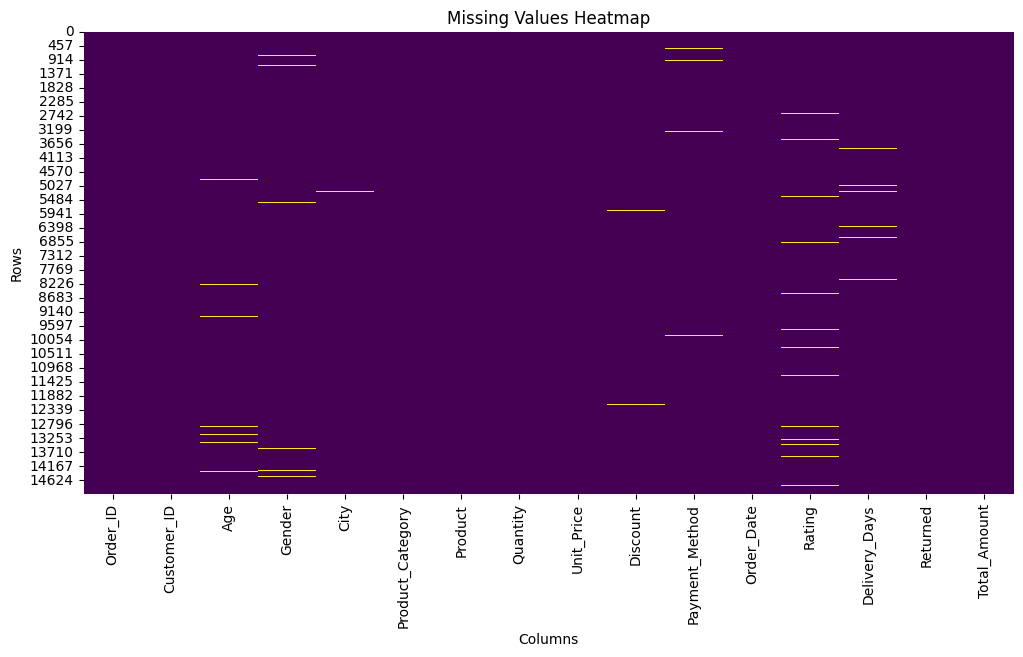

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

In [12]:
duplicates=df.duplicated().sum()
print("Duplicate records:", duplicates)

Duplicate records: 75


In [14]:
duplicate_rows = df[df.duplicated()]
print(duplicate_rows)

        Order_ID Customer_ID   Age  Gender           City Product_Category  \
232    ORD100933    CUST7882  38.0     NaN     Vijayawada          Fashion   
1123   ORD103976    CUST3601  67.0    Male      Ahmedabad      Electronics   
1274   ORD107827    CUST1775  39.0  Female      Ahmedabad           Sports   
2255   ORD111361    CUST7933  25.0    Male        Kolkata           Sports   
2311   ORD101796    CUST5636  43.0    Male           Pune          Fashion   
...          ...         ...   ...     ...            ...              ...   
14317  ORD105971    CUST5059  44.0    Male      Hyderabad          Fashion   
14605  ORD111737    CUST3702  35.0  Female         Guntur           Sports   
14662  ORD100150    CUST8539  26.0  Female          Delhi      Electronics   
14744  ORD114868    CUST6100  31.0    Male  Visakhapatnam      Electronics   
14859  ORD103018    CUST5249  29.0    Male         Guntur      Electronics   

           Product  Quantity  Unit_Price  Discount Payment_Meth

In [18]:
df["Order_ID"].duplicated().sum()
 
df = df.drop_duplicates()
 
 

In [ ]:
df.duplicated().sum()

0